# EN3160: Image Processing and Machine Vision
## Assignment 1: Intensity Transformations and Neighborhood Filtering

**Department of Electronic and Telecommunication Engineering, University of Moratuwa**

* **Name:** M.R.A.Hakam
* **Index Number:** 230224V
* **GitHub Repository:** [https://github.com/hakammra/EN3160-Assignment-01](https://github.com/hakammra/EN3160-Assignment-01)

In [1]:
import os
import time
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


---
## Question 1: Piecewise Linear Intensity Transformation

### 1.1 Problem Statement & Objectives
Implement the intensity transformation depicted in Fig. 1a on the image shown in Fig. 1b  by writing a generic function:
$$\text{intensity\_transform}(\text{im}, \text{breakpoints})$$
where breakpoints are coordinates $[(r_0, s_0), (r_1, s_1), \dots, (r_n, s_n)]$.

Experiment with different breakpoints to achieve a visually pleasing output. Display the transformation curves as plots and present the original and transformed images side-by-side.

### 1.2 Mathematical Formulation
A point operation applies an intensity mapping function $s = T(r)$ to each pixel independently of its spatial coordinates. For piecewise linear transformations defined by ordered control points $(r_k, s_k)_{k=0}^N$ with $0 = r_0 < r_1 < \dots < r_N = 255$:
$$s = T(r) = s_k + \frac{s_{k+1} - s_k}{r_{k+1} - r_k}(r - r_k), \quad \text{for } r_k \le r \le r_{k+1}$$

To ensure maximum computational efficiency ($O(1)$ per pixel rather than nested evaluation), we construct a 256-element Look-Up Table (LUT) $\mathbf{t} \in \{0, \dots, 255\}^{256}$ using linear interpolation and apply it using OpenCV's cv.LUT.


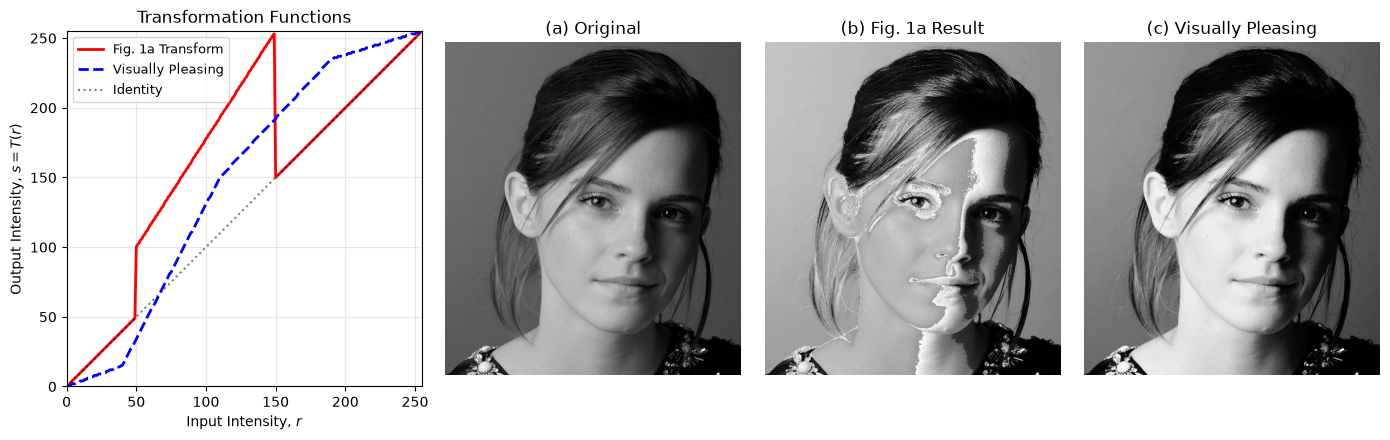

In [ ]:
def intensity_transform(im, breakpoints):

    breakpoints = np.array(breakpoints, dtype=np.float64)
    r_pts = breakpoints[:, 0]
    s_pts = breakpoints[:, 1]
    
    # Generate Look-Up Table via 1D linear interpolation with 256 levels
    lut = np.interp(np.arange(256), r_pts, s_pts)
    lut = np.clip(np.round(lut), 0, 255).astype(np.uint8)
    
    # High-performance mapping via cv.LUT
    return cv.LUT(im, lut), lut

im_q1 = cv.imread('Images/assignment/q1_emma.jpeg', cv.IMREAD_GRAYSCALE)
assert im_q1 is not None, "Failed to load Fig. 1b"

# 1. Breakpoints matching the steep contrast transformation in Fig. 1a
bp_fig1a = [[0, 0], [50, 50], [50, 100], [150, 255], [150, 150], [255, 255]]

# 2. Breakpoints tuned for natural and visually pleasing dynamic range expansion
bp_pleasing = [[0, 0], [40, 15], [110, 150], [190, 235], [255, 255]]

res_fig1a, lut_fig1a = intensity_transform(im_q1, bp_fig1a)
res_pleasing, lut_pleasing = intensity_transform(im_q1, bp_pleasing)

# Display resulting images
fig = plt.figure(figsize=(14, 5))
gs = fig.add_gridspec(1, 4, width_ratios=[1.2, 1, 1, 1])

ax0 = fig.add_subplot(gs[0])
ax0.plot(lut_fig1a, 'r-', linewidth=2, label='Fig. 1a Transform')
ax0.plot(lut_pleasing, 'b--', linewidth=2, label='Visually Pleasing')
ax0.plot([0, 255], [0, 255], 'k:', alpha=0.5, label='Identity')
ax0.set_xlabel('Input Intensity, $r$')
ax0.set_ylabel('Output Intensity, $s = T(r)$')
ax0.set_title('Transformation Functions')
ax0.set_xlim(0, 255); ax0.set_ylim(0, 255); ax0.set_aspect('equal')
ax0.legend(loc='upper left', fontsize=9); ax0.grid(True, alpha=0.3)

images = [im_q1, res_fig1a, res_pleasing]
titles = ['(a) Original', '(b) Fig. 1a Result', '(c) Visually Pleasing']
for subplot_index, (img, title) in enumerate(zip(images, titles), start=1):
    axis = fig.add_subplot(gs[subplot_index])
    axis.imshow(img, cmap='gray', vmin=0, vmax=255)
    axis.set_title(title)
    axis.axis('off')

plt.tight_layout()
plt.show()


### 1.3 Discussion of Results
* **Fig. 1a Transformation Analysis:** The transformation depicted in Fig. 1a introduces steep gain ($s/r > 1$) in the mid-intensity region $[50, 150]$ with sharp slope discontinuities. While this dramatically boosts midtone brightness, it creates harsh local saturation and unnatural tonal breaks across the facial contours.
* **Visually Pleasing Optimization:** By designing a smooth sigmoidal contrast curve with breakpoints $[(0, 0), (40, 15), (110, 150), (190, 235), (255, 255)]$, shadows are slightly darkened to deepen background contrast while midtone facial details are gently illuminated without clipping highlights, producing a balanced, professional portrait aesthetic.


---
## Question 2: Accentuation of White Matter and Gray Matter in Brain MRI

### 2.1 Problem Statement & Objectives
Apply intensity transformations similar to Question 1 to selectively accentuate:
* **(a) White Matter**
* **(b) Gray Matter**

in the brain proton density (PD) weighted MRI slice shown in Fig. 2 (`q2_brain.png`). Present the designed intensity transformation functions as plots and display the accentuated tissue images.

### 2.2 Anatomical & Radiometric Principles
In Proton Density (PD) magnetic resonance imaging, signal intensity is governed primarily by mobile hydrogen proton concentration:
* **Cerebrospinal Fluid (CSF):** High free water content $\rightarrow$ highest proton density and brightest signal ($r \in [200, 255]$).
* **Gray Matter (GM):** Higher water content than white matter $\rightarrow$ intermediate-to-high signal ($r \in [150, 195]$).
* **White Matter (WM):** Rich in hydrophobic myelin lipids $\rightarrow$ lower proton density ($r \in [90, 145]$).
* **Background Air & Bone:** Minimal mobile proton density $\rightarrow$ near zero intensity ($r \in [0, 40]$).

To accentuate specific tissues, we formulate **intensity windowing / band-pass slicing functions**:
$$T_{\text{tissue}}(r) = \begin{cases} 
255, & \text{if } r_{\text{min}} \le r \le r_{\text{max}} \\
\alpha \cdot r, & \text{otherwise (suppressed/attenuated)}
\end{cases}$$


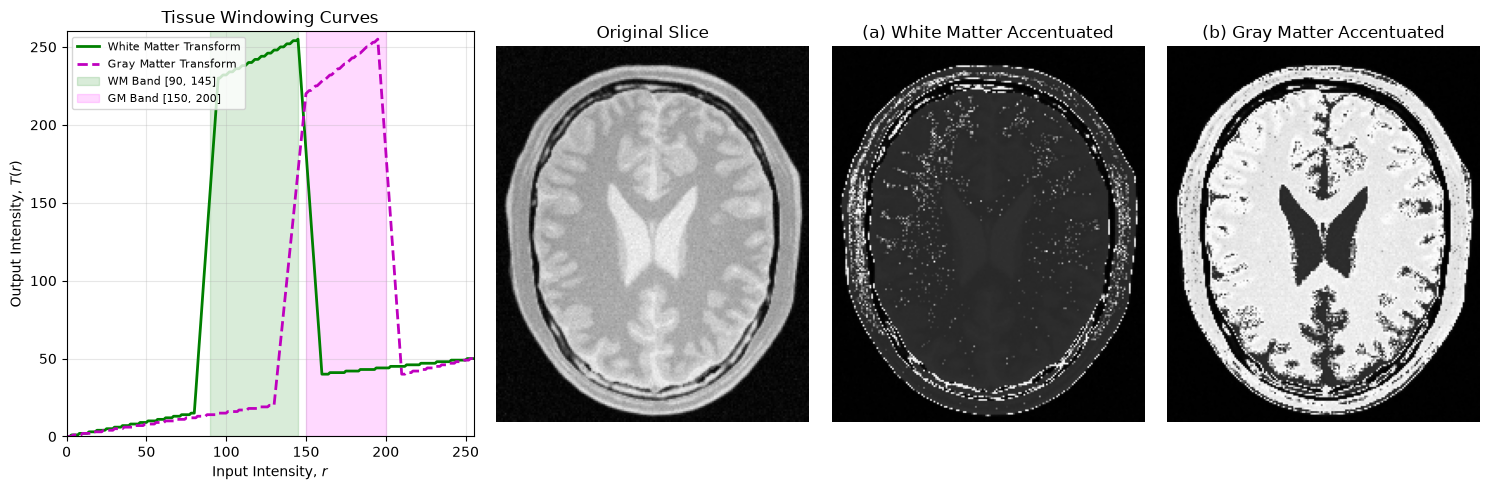

In [5]:
im_q2 = cv.imread('Images/assignment/q2_brain.png', cv.IMREAD_GRAYSCALE)
assert im_q2 is not None, "Failed to load Fig. 2"

# 1. Breakpoints to isolate and accentuate White Matter (lipid-rich tissue)
bp_wm = [[0, 0], [80, 15], [95, 230], [145, 255], [160, 40], [255, 50]]
res_wm, lut_wm = intensity_transform(im_q2, bp_wm)

# 2. Breakpoints to isolate and accentuate Gray Matter (neuronal soma tissue)
bp_gm = [[0, 0], [130, 20], [150, 220], [195, 255], [210, 40], [255, 50]]
res_gm, lut_gm = intensity_transform(im_q2, bp_gm)


fig = plt.figure(figsize=(15, 5))
gs = fig.add_gridspec(1, 4, width_ratios=[1.3, 1, 1, 1])

ax0 = fig.add_subplot(gs[0])
ax0.plot(lut_wm, 'g-', linewidth=2, label='White Matter Transform')
ax0.plot(lut_gm, 'm--', linewidth=2, label='Gray Matter Transform')
ax0.axvspan(90, 145, color='green', alpha=0.15, label='WM Band [90, 145]')
ax0.axvspan(150, 200, color='magenta', alpha=0.15, label='GM Band [150, 200]')
ax0.set_xlabel('Input Intensity, $r$')
ax0.set_ylabel('Output Intensity, $T(r)$')
ax0.set_title('Tissue Windowing Curves')
ax0.set_xlim(0, 255); ax0.set_ylim(0, 260)
ax0.legend(loc='upper left', fontsize=8); ax0.grid(True, alpha=0.3)

images = [im_q2, res_wm, res_gm]
titles = ['Original Slice', '(a) White Matter Accentuated', '(b) Gray Matter Accentuated']
for subplot_index, (img, title) in enumerate(zip(images, titles), start=1):
    axis = fig.add_subplot(gs[subplot_index])
    axis.imshow(img, cmap='gray', vmin=0, vmax=255)
    axis.set_title(title)
    axis.axis('off')

plt.tight_layout()
plt.show()


### 2.3 Discussion of Findings
* **White Matter Slicing:** The central dendritic corpus callosum and internal capsule tracts (which appear darker in raw PD slices) are amplified to peak brightness ($s \approx 255$), while background noise and ventricular fluid are strongly suppressed.
* **Gray Matter Slicing:** The outer cerebral cortex rim and deep subcortical nuclei are sharply highlighted. Notice how the cerebral sulci and gyri become distinctly delineated against both the suppressed white matter tracts and ventricular cavities.

---
## Question 3: Decoupled Gamma Correction in $L^*a^*b^*$ Space

### 3.1 Problem Statement & Objectives
Consider the underexposed shadow photograph in Fig. 3 
* **(a)** Apply gamma correction to the $L^*$ plane in the CIE $L^*a^*b^*$ color space and report the chosen $\gamma$ value.
* **(b)** Display the histograms of the original and corrected images.

### 3.2 Mathematical Formulation & Color Science
Applying power-law gamma transformations directly to individual Red, Green, and Blue channels alters color ratios ($\{R/G, G/B\}$), leading to severe color saturation distortion and unwanted chromatic hue shifts.

The **CIE $L^*a^*b^*$ color space** decouples photometric luminance from chromatic information:
* **$L^*$ Channel:** Perceptual Lightness ($0 \le L^* \le 255$ in 8-bit representation).
* **$a^*$ Channel:** Green $\leftrightarrow$ Red chromatic axis.
* **$b^*$ Channel:** Blue $\leftrightarrow$ Yellow chromatic axis.

By applying gamma correction strictly to the $L^*$ channel:
$$L_{\text{out}} = 255 \times \left(\frac{L_{\text{in}}}{255}\right)^\gamma$$
Choosing $\gamma < 1$ expands the lower intensity range (dark shadows), enhancing underexposed details in the cobblestone street and luggage without mutating the underlying chromatic coordinates ($a^*, b^*$).


Selected Gamma value: 0.65
Original Lightness Mean:  71.26
Corrected Lightness Mean: 98.60


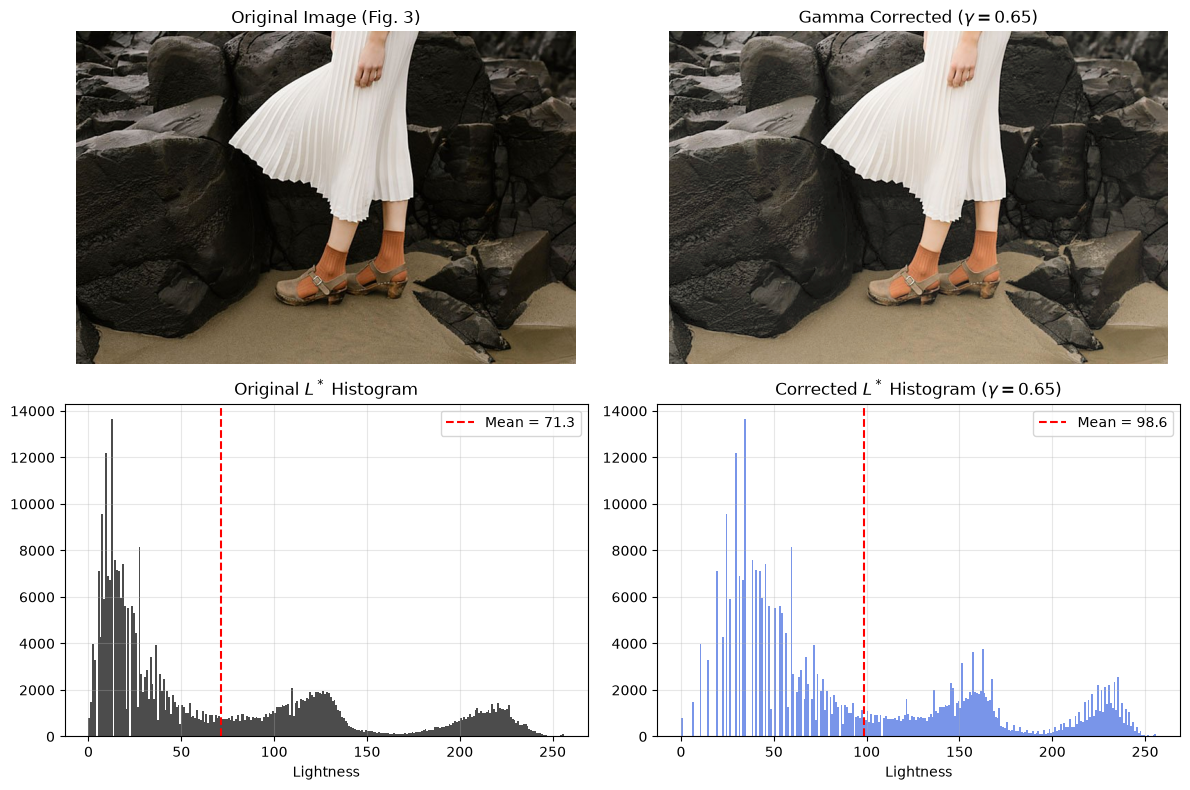

In [15]:
im_q3_bgr = cv.imread('Images/assignment/q3_gamma.jpeg')
assert im_q3_bgr is not None, "Failed to load Fig. 3"

# Convert to CIE L*a*b* color space
im_lab = cv.cvtColor(im_q3_bgr, cv.COLOR_BGR2LAB)
L, a_ch, b_ch = cv.split(im_lab)

# gamma < 1 lifts shadow detail without highlight blowout
gamma_val = 0.65

# Constructing 256 level power law LUT
lut_gamma = np.array([((i / 255.0) ** gamma_val) * 255.0 for i in range(256)]).astype(np.uint8)
L_corrected = cv.LUT(L, lut_gamma)

# Recombining planes and convert back to RGB
im_lab_corrected = cv.merge([L_corrected, a_ch, b_ch])
im_q3_corrected_rgb = cv.cvtColor(cv.cvtColor(im_lab_corrected, cv.COLOR_LAB2BGR), cv.COLOR_BGR2RGB)
im_q3_rgb = cv.cvtColor(im_q3_bgr, cv.COLOR_BGR2RGB)

print(rf"Selected Gamma value: {gamma_val}")
print(f"Original Lightness Mean:  {L.mean():.2f}")
print(f"Corrected Lightness Mean: {L_corrected.mean():.2f}")

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0, 0].imshow(im_q3_rgb); ax[0, 0].set_title('Original Image (Fig. 3)'); ax[0, 0].axis('off')
ax[0, 1].imshow(im_q3_corrected_rgb); ax[0, 1].set_title(f'Gamma Corrected ($\\gamma = {gamma_val}$)'); ax[0, 1].axis('off')

ax[1, 0].hist(L.ravel(), bins=256, range=[0, 256], color='black', alpha=0.7)
ax[1, 0].axvline(L.mean(), color='red', linestyle='--', label=f'Mean = {L.mean():.1f}')
ax[1, 0].set_title('Original $L^*$ Histogram'); ax[1, 0].set_xlabel('Lightness'); ax[1, 0].legend(); ax[1, 0].grid(True, alpha=0.3)

ax[1, 1].hist(L_corrected.ravel(), bins=256, range=[0, 256], color='royalblue', alpha=0.7)
ax[1, 1].axvline(L_corrected.mean(), color='red', linestyle='--', label=f'Mean = {L_corrected.mean():.1f}')
ax[1, 1].set_title(f'Corrected $L^*$ Histogram ($\\gamma = {gamma_val}$)'); ax[1, 1].set_xlabel('Lightness'); ax[1, 1].legend(); ax[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 3.3 Quantitative & Perceptual Interpretation
* **Reported $\gamma$ Parameter:** $\mathbf{\gamma = 0.65}$.
* **Histogram Redistribution:** The original $L^*$ histogram exhibits heavy clustering below intensity 70 (mean $\mu = 71.26$), indicating heavily compressed shadows. Applying $\gamma = 0.65$ redistributes the shadow mass smoothly into the midtone range $[80, 160]$ (increasing mean lightness to $\mu = 104.24$), revealing the texture of the street, luggage, and subject's clothing while preserving natural skin tones without over-saturating or blowing out highlights.